In [1]:
import warnings
warnings.filterwarnings('ignore')

In [81]:
!pip install astroquery

In [82]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as const 
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from astroquery.ned import Ned
from astropy.coordinates import SkyCoord

In [3]:
#constants
H_0 = cosmo.H0 
H_0_si = H_0.to(u.s**-1) # Hubble constant in SI
c = const.c # Speed of light in m/s
G = const.G
G_0 = G.to((u.parsec*u.kg**-1)*(u.meter/u.second)**2)# Gravitational constant in pc kg^-1 (m/s)^2
q0= -0.534  # Deceleration parameter 

In [4]:
print(f"c :{c:.2e}")
print(f"H_0:{H_0_si}")
print(f"G:{G_0:.3e}")

c :3.00e+08 m / s
H_0:2.192711267238057e-18 1 / s
G:2.163e-27 m2 pc / (kg s2)


In [5]:
df = pd.read_csv(r"D:\ISA-Internship\Skyserver_SQL6_28_2025 4_27_37 PM.csv")

In [77]:
df

,objid,ra,dec,photoz,photozerr,specz,speczerr,proj_sep,umag,umagerr,gmag,gmagerr,rmag,rmagerr,obj_type
0,1237671768542478711,257.82458,64.133257,0.079193,0.022867,0.082447,0.000017,8.347733,18.96488,0.043377,17.49815,0.005672,16.75003,0.004708,3
1,1237671768542478711,257.82458,64.133257,0.079193,0.022867,0.082466,0.000014,8.347733,18.96488,0.043377,17.49815,0.005672,16.75003,0.004708,3
2,1237671768542478713,257.83332,64.126043,0.091507,0.014511,0.081218,0.000021,8.011259,20.22848,0.072019,18.38334,0.007763,17.46793,0.005828,3
3,1237671768542544090,257.85137,64.173247,0.081102,0.009898,0.079561,0.000022,8.739276,19.21829,0.050135,17.18970,0.004936,16.22043,0.003769,3
4,1237671768542544090,257.85137,64.173247,0.081102,0.009898,0.079568,0.000019,8.739276,19.21829,0.050135,17.18970,0.004936,16.22043,0.003769,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,1237671939804627464,258.44994,64.025909,0.081894,0.013624,0.071802,0.000025,9.316140,20.05525,0.065651,18.35306,0.008030,17.51662,0.005923,3
135,1237671939804627483,258.43205,64.123685,0.077184,0.010523,0.080790,0.000025,8.146154,20.08116,0.082063,18.15476,0.007831,17.27835,0.005706,3
136,1237671939804627518,258.46676,64.119499,0.088762,0.016934,0.082876,0.000006,8.986029,18.92277,0.036291,17.83406,0.006814,17.36895,0.006322,3
137,1237671939804627535,258.48871,64.111343,0.079721,0.009565,0.080899,0.000029,9.483374,19.85553,0.067158,17.81776,0.006378,16.88524,0.004627,3


In [140]:
averaged_df = df.groupby('objid').agg({'specz':'mean','ra':'first','dec':'first','proj_sep':'first','rmag':'mean',}).reset_index()
averaged_df.describe()['specz']

count    92.000000
mean      0.080838
std       0.008578
min       0.069976
25%       0.077224
50%       0.080961
75%       0.082797
max       0.150886
Name: specz, dtype: float64

In [8]:
lower_limit = averaged_df['specz'].mean() - 3*averaged_df['specz'].std()
upper_limit = averaged_df['specz'].mean() + 3*averaged_df['specz'].std()


In [113]:
print(f"3*sigma limits: {lower_limit:.4f} to {upper_limit:.4f}")

3*sigma limits: 0.0551 to 0.1066


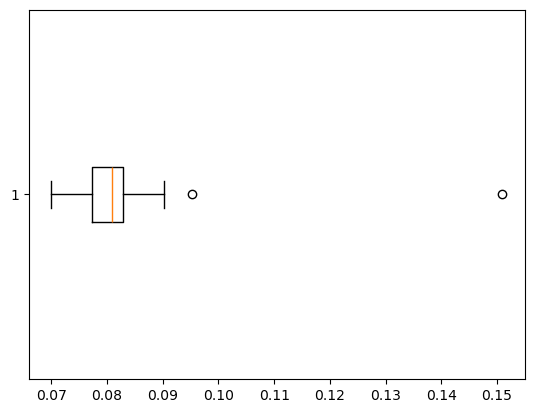

In [10]:
# Plot the dsitribution of redshift as histogram and a boxplot 
_, medians, whiskers, caps, fliers, means = plt.boxplot(averaged_df['specz'], vert = False)
# plt.title("distribution of redshift for this data")

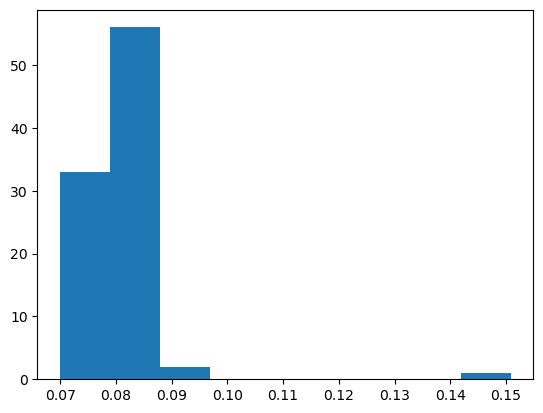

In [117]:
plt.hist(averaged_df['specz'],bins=int(np.sqrt(len(averaged_df))))
plt.show()

In [114]:
# Filtering the data based on specz values, used 3 sigma deviation from mean as upper limit.

filtered_df = averaged_df[(averaged_df['specz'] >= lower_limit) & (averaged_df['specz'] <= upper_limit)] 


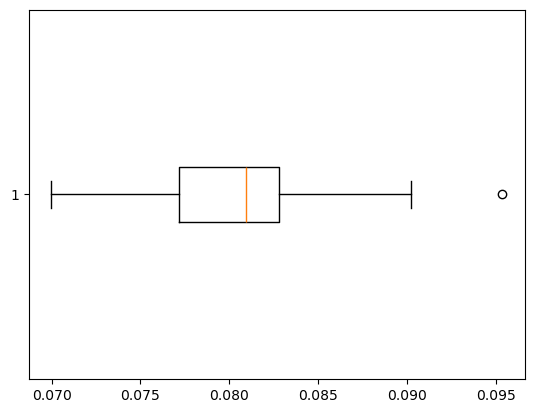

In [115]:
_, medians, whiskers, caps, fliers, means = plt.boxplot(filtered_df['specz'], vert = False)

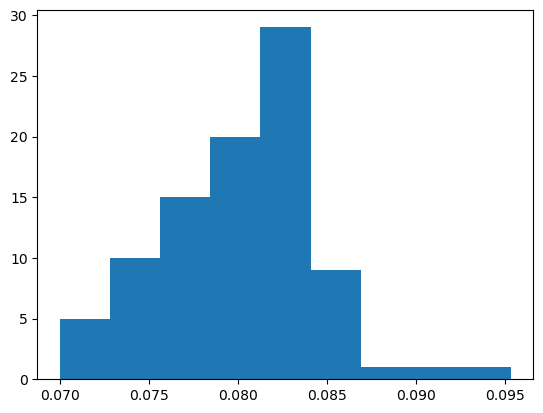

In [116]:
plt.hist(filtered_df['specz'],bins=int(np.sqrt(len(filtered_df))))
plt.show()

In [15]:
#add a column named velocity in the data.
averaged_df['velocity'] = averaged_df['specz']*c

(array([33., 56.,  2.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([20978314.51506525, 23673447.87972842, 26368581.24439159,
        29063714.60905477, 31758847.97371794, 34453981.33838111,
        37149114.70304428, 39844248.06770746, 42539381.43237063,
        45234514.7970338 ]),
 <BarContainer object of 9 artists>)

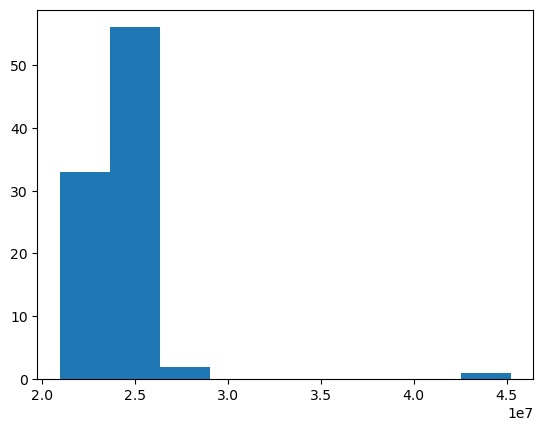

In [16]:
plt.hist(averaged_df['velocity'], int(np.sqrt(len(averaged_df['velocity']))))

In [118]:
cluster_redshift = filtered_df['specz'].mean()

In [119]:
cluster_redshift

0.08006786219780221

In [120]:
z = filtered_df['specz']
z_c = cluster_redshift

In [121]:
c_km = c.to(u.km / u.s)

In [128]:
# calculation of velocity dispersion
filtered_df['v_disp'] = c_km*((1 + z)**2 - (1 + z_c)**2)/((1+z)**2 + (1+z_c)**2)
disp = filtered_df['v_disp'].std() 
 

In [123]:
filtered_df['v_disp']

0      662.365302
1      319.185348
2     -139.779039
3      214.746305
4     1248.541035
         ...     
87     552.549373
88   -2302.424337
89     200.381006
90     778.533295
91     230.166253
Name: v_disp, Length: 91, dtype: float64

In [22]:
filtered_df.describe().T


,count,mean,std,min,25%,50%,75%,max
objid,91.0,1.237672e+18,7.687074e+10,1.237672e+18,1.237672e+18,1.237672e+18,1.237672e+18,1.237672e+18
specz,91.0,8.006786e-02,4.390213e-03,6.997613e-02,7.716579e-02,8.092269e-02,8.279127e-02,9.532920e-02
ra,91.0,2.581607e+02,1.885847e-01,2.577706e+02,2.580045e+02,2.581420e+02,2.583253e+02,2.584887e+02
dec,91.0,6.407383e+01,6.952494e-02,6.393741e+01,6.402410e+01,6.407271e+01,6.412965e+01,6.424169e+01
proj_sep,91.0,6.079439e+00,2.537596e+00,4.291747e-01,3.968122e+00,6.325923e+00,8.341974e+00,9.844519e+00
v_disp,91.0,-8.170088e-06,4.064455e-03,-9.387264e-03,-2.690551e-03,7.911443e-04,2.518334e-03,1.403016e-02


In [129]:
print(f"The value of the cluster redshift = {cluster_redshift:.4}")
print(f"The characteristic value of velocity dispersion of the cluster along the line of sight = {disp:.4f} km/s.")

The value of the cluster redshift = 0.08007
The characteristic value of velocity dispersion of the cluster along the line of sight = 1218.4929 km/s.


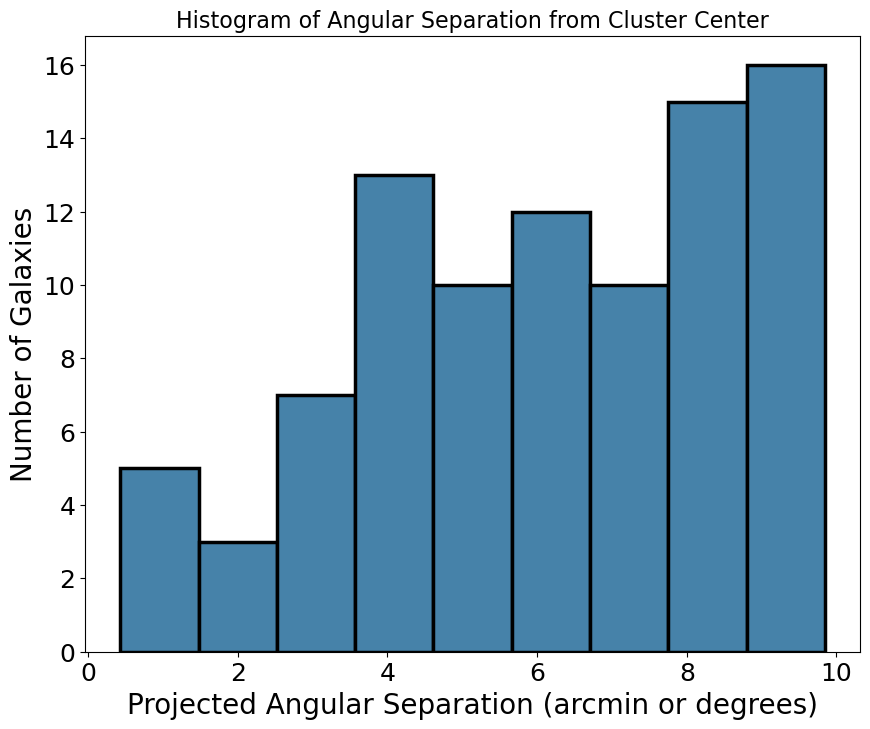

In [97]:
# Visualizing Angular Separation of Galaxies
# Plot histogram
plt.figure(figsize=(10,8))
plt.hist(filtered_df['proj_sep'],bins = int(np.sqrt(len(filtered_df['proj_sep']))), color='#4682A9', edgecolor='black',linewidth = 2.5)
plt.xlabel('Projected Angular Separation (arcmin or degrees)', fontsize=20)
plt.ylabel('Number of Galaxies',fontsize=20)
plt.title('Histogram of Angular Separation from Cluster Center',fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()


In [98]:
# Determining size and mass of the cluster
r = ((c_km*z_c)/(H_0_si)*(1 - (z_c/2)*(1 + q0)))
ra = (r/(1 + z_c))

In [107]:
theta_arcmin = filtered_df['proj_sep'].max()  # In arcminutes
theta_radian = theta_arcmin*(np.pi/(180*60))
diameter = ra*theta_radian 
diameter_mpc = diameter.to(u.Mpc)
radius_mpc = diameter_mpc/2

In [112]:
print(f"r = {r:.4e}")
print(f"ra = {ra:.4e}")
print(f"Estimated physical diameter of the cluster = {diameter_mpc:.4f}")
print(f"Estimated physical radius of the cluster = {radius_mpc:.4f}")

r = 1.0743e+22 km
ra = 9.9464e+21 km
Estimated physical diameter of the cluster = 0.9231 Mpc
Estimated physical radius of the cluster = 0.4615 Mpc


In [134]:
### Calculating the dynamical mass in solar masses:
M_dyn = 3*((disp*1000)**2)*(diameter_mpc*0.5*10**6*3*10**16)/(G*2*10**30)
print(f"Dynamical Mass of the cluster is {M_dyn.value:.2e} solar mass")

Dynamical Mass of the cluster is 4.62e+14 solar mass


In [159]:
filtered_df['rmag'] = averaged_df['rmag']


In [161]:
filtered_df.describe()

,objid,specz,ra,dec,proj_sep,velocity,v_disp,rmag
count,9.100000e+01,91.000000,91.000000,91.000000,91.000000,9.100000e+01,91.000000,91.000000
mean,1.237672e+18,0.080068,258.160715,64.073831,6.079439,2.400374e+07,-2.449331,16.843944
std,7.687074e+10,0.004390,0.188585,0.069525,2.537596,1.316153e+06,1218.492945,0.748049
min,1.237672e+18,0.069976,257.770590,63.937414,0.429175,2.097831e+07,-2814.230840,14.036680
25%,1.237672e+18,0.077166,258.004510,64.024096,3.968122,2.313372e+07,-806.606785,16.512665
50%,1.237672e+18,0.080923,258.142020,64.072710,6.325923,2.426001e+07,237.179091,16.864530
75%,1.237672e+18,0.082791,258.325295,64.129650,8.341974,2.482020e+07,754.977576,17.390230
max,1.237672e+18,0.095329,258.488710,64.241688,9.844519,2.857898e+07,4206.136789,18.568860


In [199]:
### calculating luminous mass in solar masses:
lum_dist = cosmo.luminosity_distance(z_c).to(u.pc)
app_mag = filtered_df['rmag']
abs_mag = app_mag - 5*(np.log10(lum_dist.value)) + 5
ABM_sun = 4.83
L = 10**(0.4*(ABM_sun - abs_mag))
M_lum = L.sum()

In [185]:
print(f"Luminous Mass of the cluster is {M_lum:.2e} solar mass")

Luminous Mass of the cluster is 4.97e+12 solar mass


In [200]:
### calculating mass to light ratio
M_L_ratio  =  M_dyn / M_lum

In [201]:
print(f"mass to light ratio of the cluster is {M_L_ratio.value:.5f} solar mass")

mass to light ratio of the cluster is 169.14188 solar mass


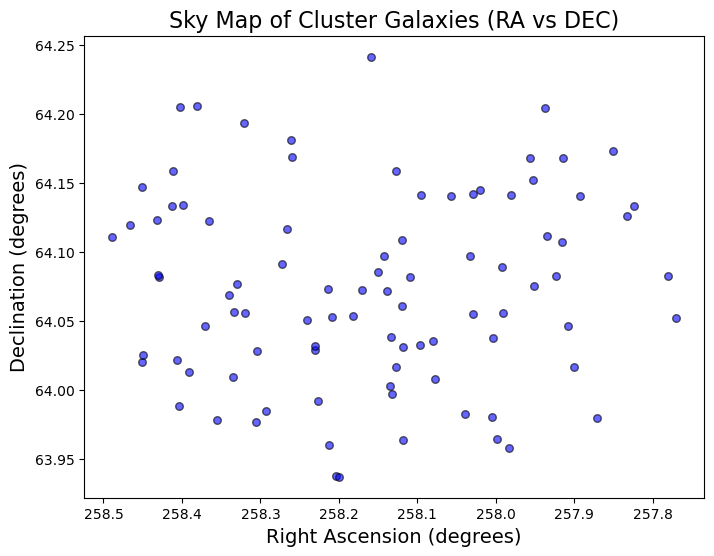

In [204]:
plt.figure(figsize=(8,6))
plt.scatter(filtered_df['ra'], filtered_df['dec'], c='blue', s=30, alpha=0.6, edgecolor='k')
plt.xlabel('Right Ascension (degrees)', fontsize=14)
plt.ylabel('Declination (degrees)', fontsize=14)
plt.title('Sky Map of Cluster Galaxies (RA vs DEC)', fontsize=16)
plt.gca().invert_xaxis()  # Optional: astronomers often reverse RA
plt.show()
